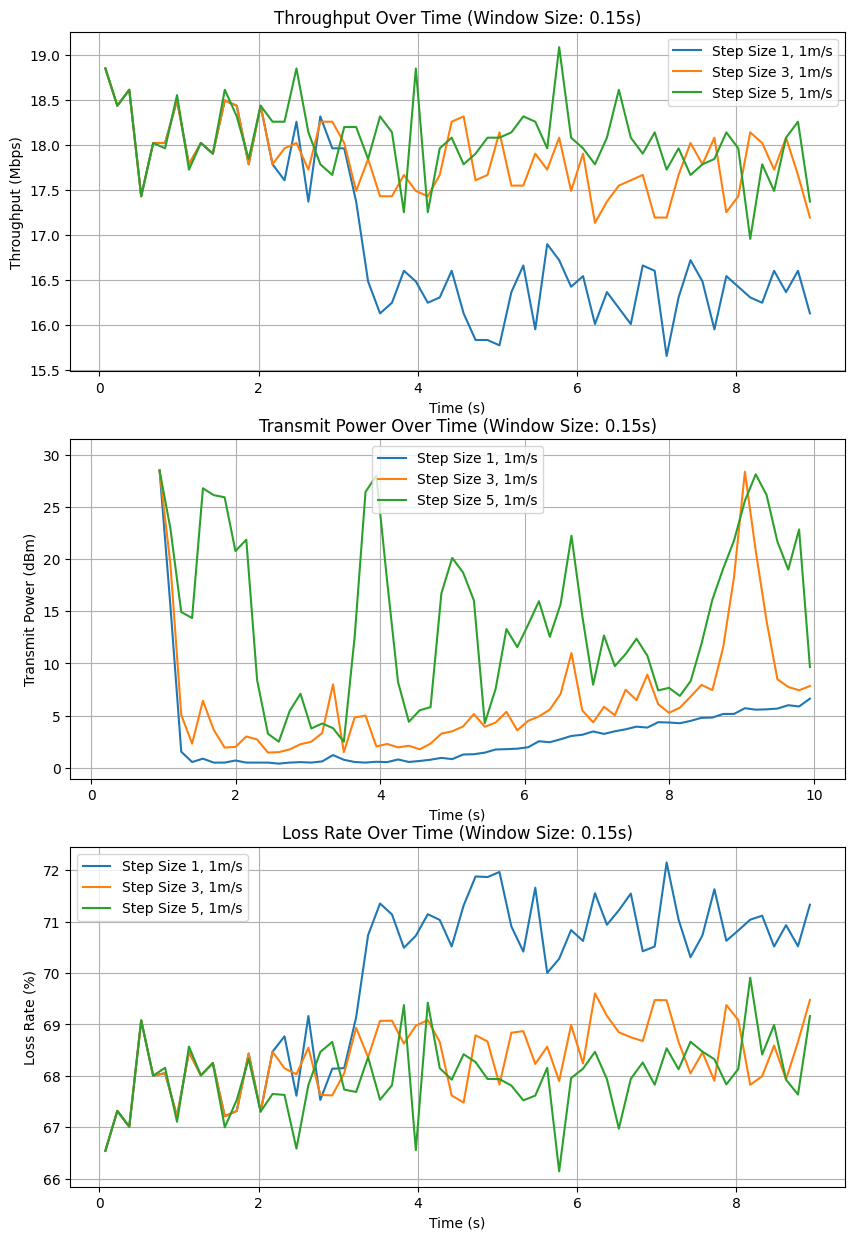

Step Size 1, 1m/s:
  - Average Throughput (MS): 16.97 Mbps
  - Average Transmit Power (AP): 3.32 dBm
  - Average Packet Loss Rate: 69.88%

Step Size 3, 1m/s:
  - Average Throughput (MS): 17.84 Mbps
  - Average Transmit Power (AP): 6.66 dBm
  - Average Packet Loss Rate: 68.36%

Step Size 5, 1m/s:
  - Average Throughput (MS): 18.05 Mbps
  - Average Transmit Power (AP): 14.57 dBm
  - Average Packet Loss Rate: 67.98%



In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the list of power step simulations
simulations = [
    ("wifi_sim_1_1.csv", "wifi_sim_ms_1_1.csv", "tx_power_1_1.txt", "Step Size 1, 1m/s"),
    ("wifi_sim_1_3.csv", "wifi_sim_ms_1_3.csv", "tx_power_1_3.txt", "Step Size 3, 1m/s"),
    ("wifi_sim_1_5.csv", "wifi_sim_ms_1_5.csv", "tx_power_1_5.txt", "Step Size 5, 1m/s")
]

# Define directory paths
base_dir = r"C:\Users\Patricia Fernández\Desktop\universidad\tercero\UCR\WINTER\CS169\project 2"
csv_ap_dir = os.path.join(base_dir, "csv", "n1_i1(AP)")
csv_ms_dir = os.path.join(base_dir, "csv", "n0_i1(MS)")
txt_dir = os.path.join(base_dir, "txt")

# Initialize figure for subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))  # Three subplots: Throughput, Tx Power, Loss Rate

# Store average values
avg_throughputs = []
avg_tx_powers = []
avg_loss_rates = []

# Define the sliding window size and step size
window_size = 0.15  # 150ms window
step_size = 0.15  # Calculate every 150ms

# Loop through each simulation
for csv_ap_file, csv_ms_file, txt_file, label in simulations:
    csv_ap_path = os.path.join(csv_ap_dir, csv_ap_file)
    csv_ms_path = os.path.join(csv_ms_dir, csv_ms_file)
    txt_path = os.path.join(txt_dir, txt_file)
    
    # Load the CSV file (WiFi data from AP)
    df_ap = pd.read_csv(csv_ap_path, names=["time", "src_port", "dst_port", "len"], sep=",").dropna()
    df_ap["time"] = df_ap["time"].astype(float)
    df_ap["len"] = df_ap["len"].astype(float)

    # Load the CSV file (WiFi data from MS)
    df_ms = pd.read_csv(csv_ms_path, names=["time", "src_port", "dst_port", "len"], sep=",").dropna()
    df_ms["time"] = df_ms["time"].astype(float)
    df_ms["len"] = df_ms["len"].astype(float)

    # Determine the range of time values
    # Added a start and end time because, if not, the different step sizes would have been very similar, not notorious differences
    start_time = min(df_ap["time"].min(), df_ms["time"].min())
    end_time = max(df_ap["time"].max(), df_ms["time"].max())

    # Generate throughput values
    time_values = np.arange(start_time + window_size / 2, end_time, step_size)
    throughputs_ms = []
    loss_rates = []

    for t in time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2

        # Throughput calculation
        total_bytes_ms = df_ms[(df_ms["time"] >= window_start) & (df_ms["time"] < window_end)]["len"].sum()
        throughput_mbps_ms = (total_bytes_ms * 8) / (window_size * 1e6)  # Convert to Mbps
        throughputs_ms.append([t, throughput_mbps_ms])

        # Loss Rate calculation
        total_bytes_ap = df_ap[(df_ap["time"] >= window_start) & (df_ap["time"] < window_end)]["len"].sum()
        if total_bytes_ap > 0:
            loss_rate = (total_bytes_ap - total_bytes_ms) / total_bytes_ap * 100  # Percentage
        else:
            loss_rate = 0
        
        loss_rates.append([t, loss_rate])

    throughputs_ms = np.array(throughputs_ms)
    loss_rates = np.array(loss_rates)

    avg_throughputs.append(throughputs_ms[:, 1].mean())  # Store average throughput
    avg_loss_rates.append(loss_rates[:, 1].mean())  # Store average loss rate

    # Plot throughput
    axs[0].plot(throughputs_ms[:, 0], throughputs_ms[:, 1], label=label)

    # Load the TX power data
    tx_power_data = []
    with open(txt_path, "r") as file:
        for line in file:
            if "New Power" in line:
                parts = line.split(",")
                time_part = float(parts[0].split(" ")[1][:-1])  # Extract time
                power_part = float(parts[2].split(" ")[3])  # Extract power level
                tx_power_data.append((time_part, power_part))
    
    tx_power_df = pd.DataFrame(tx_power_data, columns=["time", "tx_power"])
    avg_tx_powers.append(tx_power_df["tx_power"].mean())  # Store average transmit power

    # Apply windowing to TX Power data
    tx_time_values = np.arange(tx_power_df["time"].min() + window_size / 2, tx_power_df["time"].max(), step_size)
    tx_powers = []

    for t in tx_time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2
        avg_power = tx_power_df[(tx_power_df["time"] >= window_start) & (tx_power_df["time"] < window_end)]["tx_power"].mean()
        tx_powers.append([t, avg_power])
    
    tx_powers = np.array(tx_powers)

    # Plot TX Power over time (AP only)
    axs[1].plot(tx_powers[:, 0], tx_powers[:, 1], label=label)

    # Plot Loss Rate over time
    axs[2].plot(loss_rates[:, 0], loss_rates[:, 1], label=label)

# Set labels and titles for the throughput plot
axs[0].set_title("Throughput Over Time (Window Size: 0.15s)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Throughput (Mbps)")
axs[0].legend()
axs[0].grid()

# Set labels and titles for the TX Power plot
axs[1].set_title("Transmit Power Over Time (Window Size: 0.15s)")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Transmit Power (dBm)")
axs[1].legend()
axs[1].grid()

# Set labels and titles for the Loss Rate plot
axs[2].set_title("Loss Rate Over Time (Window Size: 0.15s)")
axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Loss Rate (%)")
axs[2].legend()
axs[2].grid()

# Show the plot
plt.show()

# Print summary statistics
for i, (label, avg_thr, avg_txp, avg_loss) in enumerate(zip(
        [s[3] for s in simulations], avg_throughputs, avg_tx_powers, avg_loss_rates)):
    print(f"{label}:")
    print(f"  - Average Throughput (MS): {avg_thr:.2f} Mbps")
    print(f"  - Average Transmit Power (AP): {avg_txp:.2f} dBm")
    print(f"  - Average Packet Loss Rate: {avg_loss:.2f}%\n")


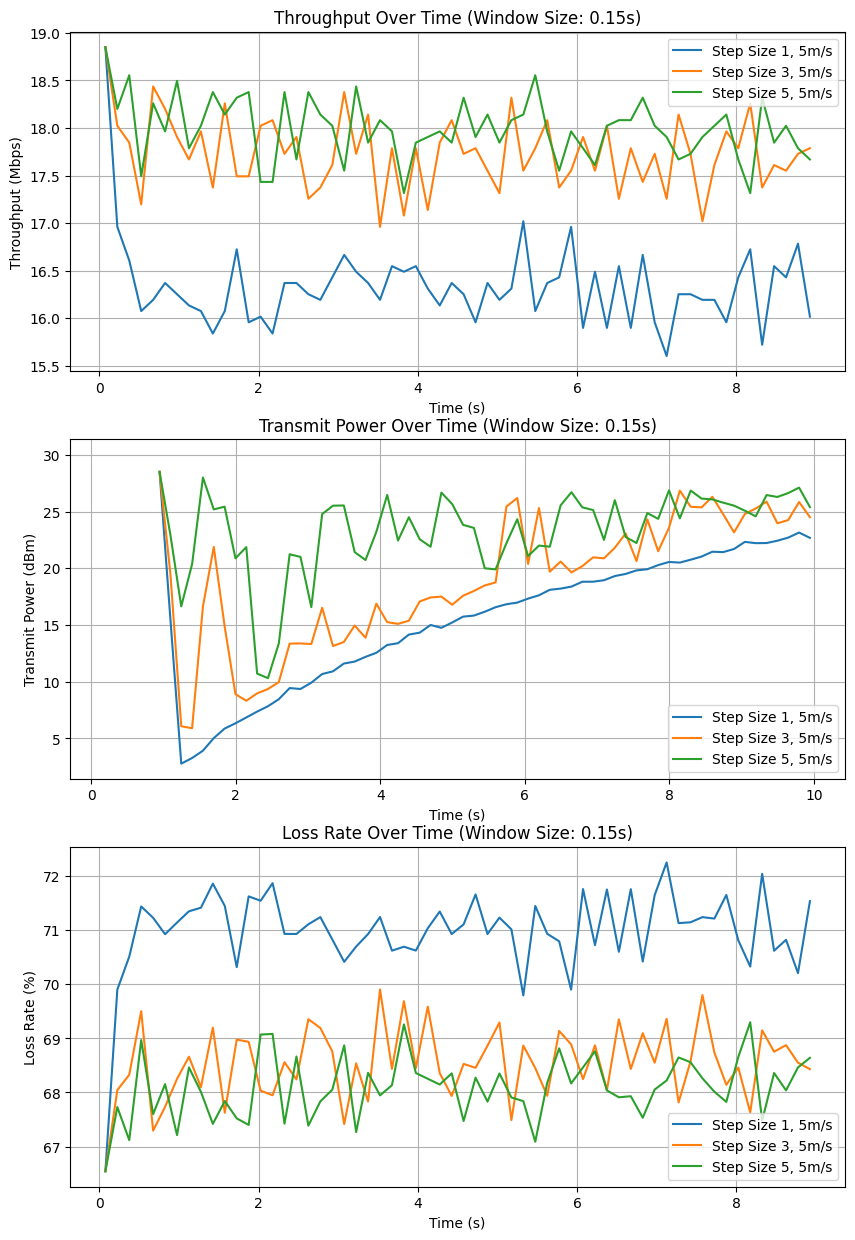

Step Size 1, 5m/s:
  - Average Throughput (MS): 16.33 Mbps
  - Average Transmit Power (AP): 15.37 dBm
  - Average Packet Loss Rate: 70.99%

Step Size 3, 5m/s:
  - Average Throughput (MS): 17.74 Mbps
  - Average Transmit Power (AP): 18.82 dBm
  - Average Packet Loss Rate: 68.54%

Step Size 5, 5m/s:
  - Average Throughput (MS): 17.99 Mbps
  - Average Transmit Power (AP): 23.17 dBm
  - Average Packet Loss Rate: 68.09%



In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the list of power step simulations
simulations = [
    ("wifi_sim_5_1.csv", "wifi_sim_ms_5_1.csv", "tx_power_5_1.txt", "Step Size 1, 5m/s"),
    ("wifi_sim_5_3.csv", "wifi_sim_ms_5_3.csv", "tx_power_5_3.txt", "Step Size 3, 5m/s"),
    ("wifi_sim_5_5.csv", "wifi_sim_ms_5_5.csv", "tx_power_5_5.txt", "Step Size 5, 5m/s")
]

# Define directory paths
base_dir = r"C:\Users\Patricia Fernández\Desktop\universidad\tercero\UCR\WINTER\CS169\project 2"
csv_ap_dir = os.path.join(base_dir, "csv", "n1_i1(AP)")
csv_ms_dir = os.path.join(base_dir, "csv", "n0_i1(MS)")
txt_dir = os.path.join(base_dir, "txt")

# Initialize figure for subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))  # Three subplots: Throughput, Tx Power, Loss Rate

# Store average values
avg_throughputs = []
avg_tx_powers = []
avg_loss_rates = []

# Define the sliding window size and step size
window_size = 0.15  # 150ms window
step_size = 0.15  # Calculate every 150ms

# Loop through each simulation
for csv_ap_file, csv_ms_file, txt_file, label in simulations:
    csv_ap_path = os.path.join(csv_ap_dir, csv_ap_file)
    csv_ms_path = os.path.join(csv_ms_dir, csv_ms_file)
    txt_path = os.path.join(txt_dir, txt_file)
    
    # Load the CSV file (WiFi data from AP)
    df_ap = pd.read_csv(csv_ap_path, names=["time", "src_port", "dst_port", "len"], sep=",").dropna()
    df_ap["time"] = df_ap["time"].astype(float)
    df_ap["len"] = df_ap["len"].astype(float)

    # Load the CSV file (WiFi data from MS)
    df_ms = pd.read_csv(csv_ms_path, names=["time", "src_port", "dst_port", "len"], sep=",").dropna()
    df_ms["time"] = df_ms["time"].astype(float)
    df_ms["len"] = df_ms["len"].astype(float)

    # Determine the range of time values
    start_time = min(df_ap["time"].min(), df_ms["time"].min())
    end_time = max(df_ap["time"].max(), df_ms["time"].max())

    # Generate throughput values (only from MS)
    time_values = np.arange(start_time + window_size / 2, end_time, step_size)
    throughputs_ms = []
    loss_rates = []

    for t in time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2

        # Throughput calculation (MS only)
        total_bytes_ms = df_ms[(df_ms["time"] >= window_start) & (df_ms["time"] < window_end)]["len"].sum()
        throughput_mbps_ms = (total_bytes_ms * 8) / (window_size * 1e6)  # Convert to Mbps
        throughputs_ms.append([t, throughput_mbps_ms])

        # Loss Rate calculation
        total_bytes_ap = df_ap[(df_ap["time"] >= window_start) & (df_ap["time"] < window_end)]["len"].sum()
        if total_bytes_ap > 0:
            loss_rate = (total_bytes_ap - total_bytes_ms) / total_bytes_ap * 100  # Percentage
        else:
            loss_rate = 0
        
        loss_rates.append([t, loss_rate])

    throughputs_ms = np.array(throughputs_ms)
    loss_rates = np.array(loss_rates)

    avg_throughputs.append(throughputs_ms[:, 1].mean())  # Store average throughput
    avg_loss_rates.append(loss_rates[:, 1].mean())  # Store average loss rate

    # Plot throughput (MS only)
    axs[0].plot(throughputs_ms[:, 0], throughputs_ms[:, 1], label=label)

    # Load the TX power data (AP only)
    tx_power_data = []
    with open(txt_path, "r") as file:
        for line in file:
            if "New Power" in line:
                parts = line.split(",")
                time_part = float(parts[0].split(" ")[1][:-1])  # Extract time
                power_part = float(parts[2].split(" ")[3])  # Extract power level
                tx_power_data.append((time_part, power_part))
    
    tx_power_df = pd.DataFrame(tx_power_data, columns=["time", "tx_power"])
    avg_tx_powers.append(tx_power_df["tx_power"].mean())  # Store average transmit power

    # Apply windowing to TX Power data
    tx_time_values = np.arange(tx_power_df["time"].min() + window_size / 2, tx_power_df["time"].max(), step_size)
    tx_powers = []

    for t in tx_time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2
        avg_power = tx_power_df[(tx_power_df["time"] >= window_start) & (tx_power_df["time"] < window_end)]["tx_power"].mean()
        tx_powers.append([t, avg_power])
    
    tx_powers = np.array(tx_powers)

    # Plot TX Power over time (AP only)
    axs[1].plot(tx_powers[:, 0], tx_powers[:, 1], label=label)

    # Plot Loss Rate over time
    axs[2].plot(loss_rates[:, 0], loss_rates[:, 1], label=label)

# Set labels and titles for the throughput plot
axs[0].set_title("Throughput Over Time (Window Size: 0.15s)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Throughput (Mbps)")
axs[0].legend()
axs[0].grid()

# Set labels and titles for the TX Power plot
axs[1].set_title("Transmit Power Over Time (Window Size: 0.15s)")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Transmit Power (dBm)")
axs[1].legend()
axs[1].grid()

# Set labels and titles for the Loss Rate plot
axs[2].set_title("Loss Rate Over Time (Window Size: 0.15s)")
axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Loss Rate (%)")
axs[2].legend()
axs[2].grid()

# Show the plot
plt.show()

# Print summary statistics
for i, (label, avg_thr, avg_txp, avg_loss) in enumerate(zip(
        [s[3] for s in simulations], avg_throughputs, avg_tx_powers, avg_loss_rates)):
    print(f"{label}:")
    print(f"  - Average Throughput (MS): {avg_thr:.2f} Mbps")
    print(f"  - Average Transmit Power (AP): {avg_txp:.2f} dBm")
    print(f"  - Average Packet Loss Rate: {avg_loss:.2f}%\n")


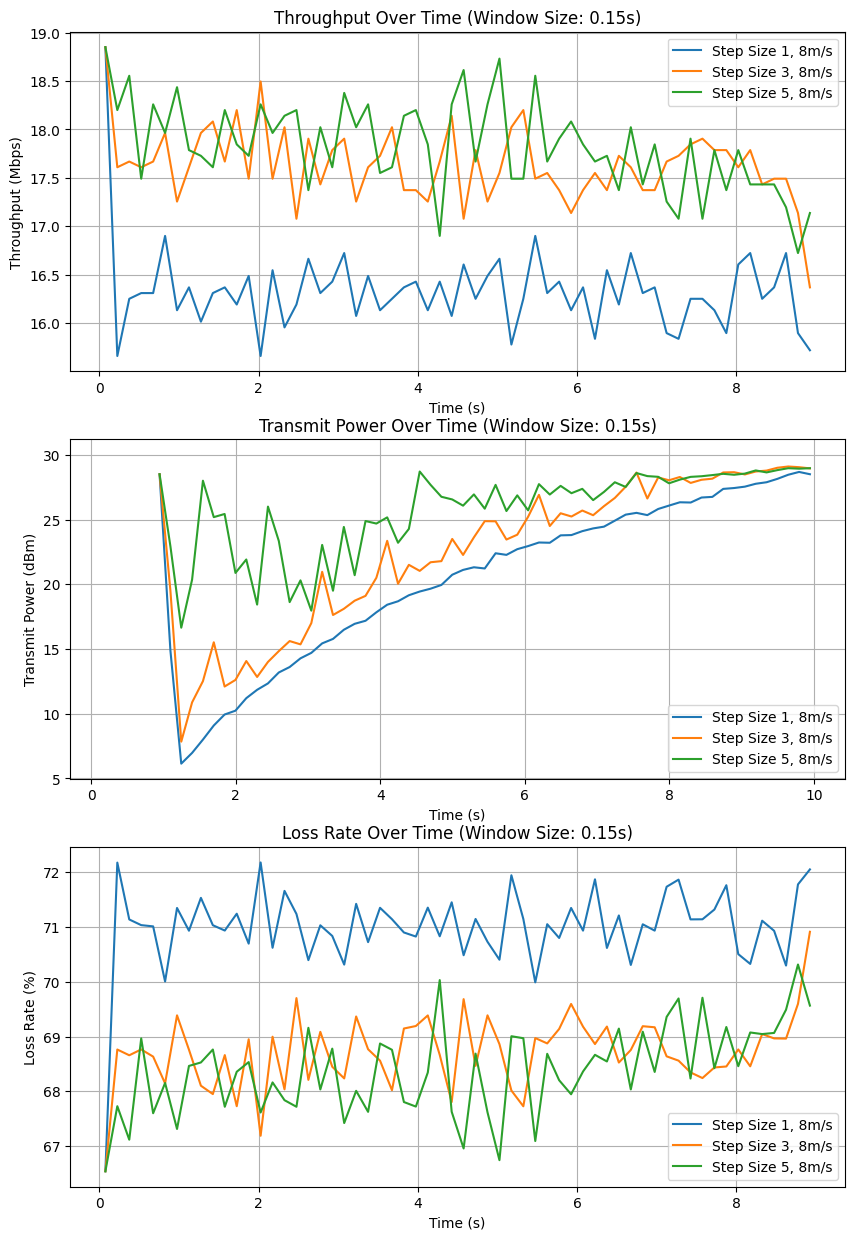

Step Size 1, 8m/s:
  - Average Throughput (MS): 16.33 Mbps
  - Average Transmit Power (AP): 20.46 dBm
  - Average Packet Loss Rate: 71.00%

Step Size 3, 8m/s:
  - Average Throughput (MS): 17.63 Mbps
  - Average Transmit Power (AP): 22.48 dBm
  - Average Packet Loss Rate: 68.71%

Step Size 5, 8m/s:
  - Average Throughput (MS): 17.82 Mbps
  - Average Transmit Power (AP): 25.66 dBm
  - Average Packet Loss Rate: 68.38%



In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the list of power step simulations
simulations = [
    ("wifi_sim_8_1.csv", "wifi_sim_ms_8_1.csv", "tx_power_8_1.txt", "Step Size 1, 8m/s"),
    ("wifi_sim_8_3.csv", "wifi_sim_ms_8_3.csv", "tx_power_8_3.txt", "Step Size 3, 8m/s"),
    ("wifi_sim_8_5.csv", "wifi_sim_ms_8_5.csv", "tx_power_8_5.txt", "Step Size 5, 8m/s")
]

# Define directory paths
base_dir = r"C:\Users\Patricia Fernández\Desktop\universidad\tercero\UCR\WINTER\CS169\project 2"
csv_ap_dir = os.path.join(base_dir, "csv", "n1_i1(AP)")
csv_ms_dir = os.path.join(base_dir, "csv", "n0_i1(MS)")
txt_dir = os.path.join(base_dir, "txt")

# Initialize figure for subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))  # Three subplots: Throughput, Tx Power, Loss Rate

# Store average values
avg_throughputs = []
avg_tx_powers = []
avg_loss_rates = []

# Define the sliding window size and step size
window_size = 0.15  # 150ms window
step_size = 0.15  # Calculate every 150ms

# Loop through each simulation
for csv_ap_file, csv_ms_file, txt_file, label in simulations:
    csv_ap_path = os.path.join(csv_ap_dir, csv_ap_file)
    csv_ms_path = os.path.join(csv_ms_dir, csv_ms_file)
    txt_path = os.path.join(txt_dir, txt_file)
    
    # Load the CSV file (WiFi data from AP)
    df_ap = pd.read_csv(csv_ap_path, names=["time", "src_port", "dst_port", "len"], sep=",").dropna()
    df_ap["time"] = df_ap["time"].astype(float)
    df_ap["len"] = df_ap["len"].astype(float)

    # Load the CSV file (WiFi data from MS)
    df_ms = pd.read_csv(csv_ms_path, names=["time", "src_port", "dst_port", "len"], sep=",").dropna()
    df_ms["time"] = df_ms["time"].astype(float)
    df_ms["len"] = df_ms["len"].astype(float)

    # Determine the range of time values
    start_time = min(df_ap["time"].min(), df_ms["time"].min())
    end_time = max(df_ap["time"].max(), df_ms["time"].max())

    # Generate throughput values (only from MS)
    time_values = np.arange(start_time + window_size / 2, end_time, step_size)
    throughputs_ms = []
    loss_rates = []

    for t in time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2

        # Throughput calculation (MS only)
        total_bytes_ms = df_ms[(df_ms["time"] >= window_start) & (df_ms["time"] < window_end)]["len"].sum()
        throughput_mbps_ms = (total_bytes_ms * 8) / (window_size * 1e6)  # Convert to Mbps
        throughputs_ms.append([t, throughput_mbps_ms])

        # Loss Rate calculation
        total_bytes_ap = df_ap[(df_ap["time"] >= window_start) & (df_ap["time"] < window_end)]["len"].sum()
        if total_bytes_ap > 0:
            loss_rate = (total_bytes_ap - total_bytes_ms) / total_bytes_ap * 100  # Percentage
        else:
            loss_rate = 0
        
        loss_rates.append([t, loss_rate])

    throughputs_ms = np.array(throughputs_ms)
    loss_rates = np.array(loss_rates)

    avg_throughputs.append(throughputs_ms[:, 1].mean())  # Store average throughput
    avg_loss_rates.append(loss_rates[:, 1].mean())  # Store average loss rate

    # Plot throughput (MS only)
    axs[0].plot(throughputs_ms[:, 0], throughputs_ms[:, 1], label=label)

    # Load the TX power data (AP only)
    tx_power_data = []
    with open(txt_path, "r") as file:
        for line in file:
            if "New Power" in line:
                parts = line.split(",")
                time_part = float(parts[0].split(" ")[1][:-1])  # Extract time
                power_part = float(parts[2].split(" ")[3])  # Extract power level
                tx_power_data.append((time_part, power_part))
    
    tx_power_df = pd.DataFrame(tx_power_data, columns=["time", "tx_power"])
    avg_tx_powers.append(tx_power_df["tx_power"].mean())  # Store average transmit power

    # Apply windowing to TX Power data
    tx_time_values = np.arange(tx_power_df["time"].min() + window_size / 2, tx_power_df["time"].max(), step_size)
    tx_powers = []

    for t in tx_time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2
        avg_power = tx_power_df[(tx_power_df["time"] >= window_start) & (tx_power_df["time"] < window_end)]["tx_power"].mean()
        tx_powers.append([t, avg_power])
    
    tx_powers = np.array(tx_powers)

    # Plot TX Power over time (AP only)
    axs[1].plot(tx_powers[:, 0], tx_powers[:, 1], label=label)

    # Plot Loss Rate over time
    axs[2].plot(loss_rates[:, 0], loss_rates[:, 1], label=label)

# Set labels and titles for the throughput plot
axs[0].set_title("Throughput Over Time (Window Size: 0.15s)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Throughput (Mbps)")
axs[0].legend()
axs[0].grid()

# Set labels and titles for the TX Power plot
axs[1].set_title("Transmit Power Over Time (Window Size: 0.15s)")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Transmit Power (dBm)")
axs[1].legend()
axs[1].grid()

# Set labels and titles for the Loss Rate plot
axs[2].set_title("Loss Rate Over Time (Window Size: 0.15s)")
axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Loss Rate (%)")
axs[2].legend()
axs[2].grid()

# Show the plot
plt.show()

# Print summary statistics
for i, (label, avg_thr, avg_txp, avg_loss) in enumerate(zip(
        [s[3] for s in simulations], avg_throughputs, avg_tx_powers, avg_loss_rates)):
    print(f"{label}:")
    print(f"  - Average Throughput (MS): {avg_thr:.2f} Mbps")
    print(f"  - Average Transmit Power (AP): {avg_txp:.2f} dBm")
    print(f"  - Average Packet Loss Rate: {avg_loss:.2f}%\n")


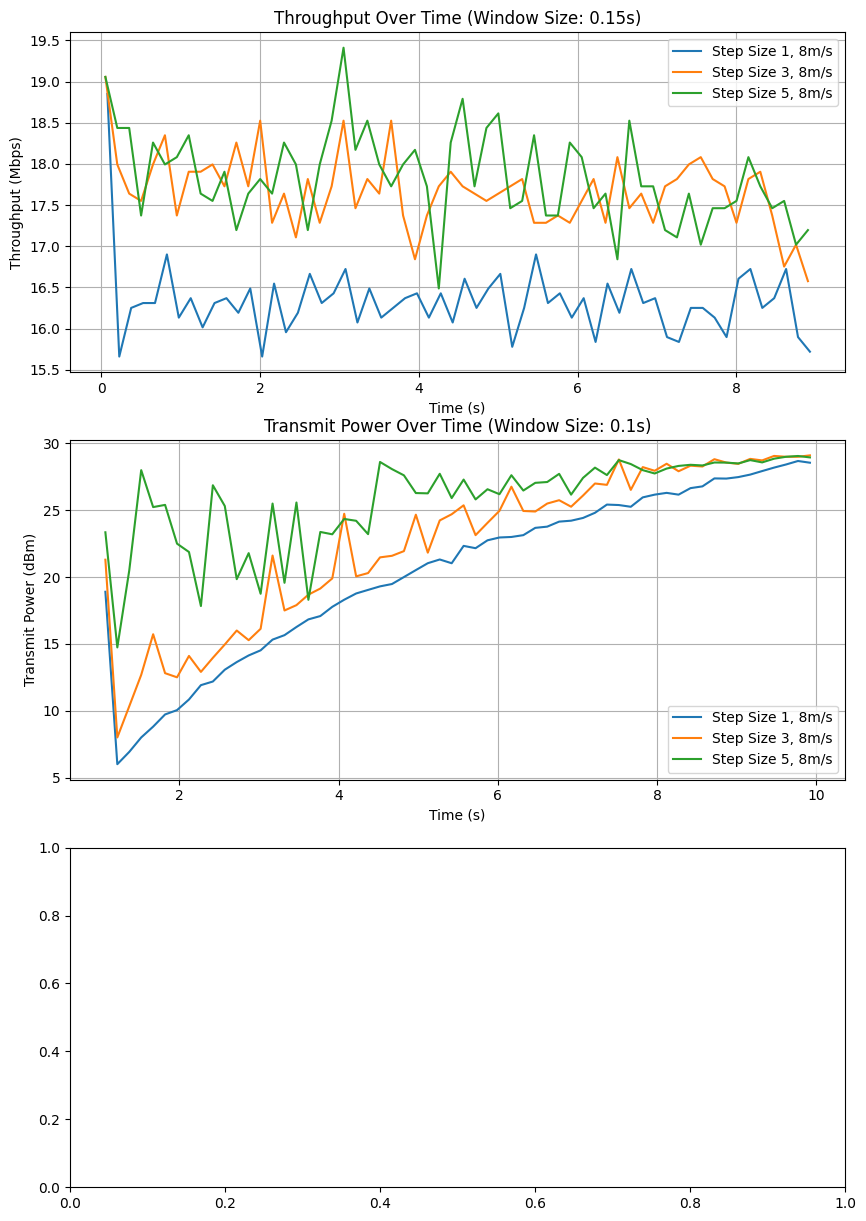

In [36]:
# NOT FINAL CODE, WAS AT THE BEGINING BUT DID NOT COMPUTE AS I WANTED 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the list of power step simulations
simulations = [
    ("wifi_sim_8_1.csv", "wifi_sim_ms_8_1.csv", "tx_power_8_1.txt", "Step Size 1, 8m/s"),
    ("wifi_sim_8_3.csv", "wifi_sim_ms_8_3.csv", "tx_power_8_3.txt", "Step Size 3, 8m/s"),
    ("wifi_sim_8_5.csv", "wifi_sim_ms_8_5.csv", "tx_power_8_5.txt", "Step Size 5, 8m/s")
]

# Define directory paths
base_dir = r"C:\Users\Patricia Fernández\Desktop\universidad\tercero\UCR\WINTER\CS169\project 2"
csv_ap_dir = os.path.join(base_dir, "csv", "n1_i1(AP)")
csv_ms_dir = os.path.join(base_dir, "csv", "n0_i1(MS)")
txt_dir = os.path.join(base_dir, "txt")

# Initialize figure for subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))  # Three subplots: Throughput, Tx Power, Loss Rate

# Store average values
avg_throughputs = []
avg_tx_powers = []
avg_loss_rates = []

# Define the sliding window size and step size
window_size = 0.15  # 150ms window
step_size = 0.15  # Calculate every 150ms

# Loop through each simulation
for csv_ap_file, csv_ms_file, txt_file, label in simulations:
    csv_ap_path = os.path.join(csv_ap_dir, csv_ap_file)
    csv_path = os.path.join(csv_ms_dir, csv_ms_file)
    txt_path = os.path.join(txt_dir, txt_file)
    
    # Load the CSV file (WiFi data)
    df = pd.read_csv(csv_path, names=["time", "src_port", "dst_port", "len"], sep=",")
    df = df.dropna()
    df["time"] = df["time"].astype(float)
    df["len"] = df["len"].astype(float)

    # Determine the range of time values
    start_time = df["time"].min()
    end_time = df["time"].max()

    # Generate throughput values
    time_values = np.arange(start_time + window_size / 2, end_time, step_size)
    throughputs = []

    for t in time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2
        total_bytes = df[(df["time"] >= window_start) & (df["time"] < window_end)]["len"].sum()
        throughput_mbps = (total_bytes * 8) / (window_size * 1e6)  # Convert to Mbps
        throughputs.append([t, throughput_mbps])
    
    throughputs = np.array(throughputs)
    avg_throughputs.append(throughputs[:, 1].mean())  # Store average throughput
    
    # Plot throughput for each step size
    axs[0].plot(throughputs[:, 0], throughputs[:, 1], label=label)

    # Define the sliding window size
    window_size = 0.1  # 100ms window
    
    # Load the TX power data
    tx_power_data = []
    with open(txt_path, "r") as file:
        for line in file:
            if "New Power" in line:
                parts = line.split(",")
                time_part = float(parts[0].split(" ")[1][:-1])  # Extract time
                power_part = float(parts[2].split(" ")[3])  # Extract power level
                tx_power_data.append((time_part, power_part))
    
    tx_power_df = pd.DataFrame(tx_power_data, columns=["time", "tx_power"])
    avg_tx_powers.append(tx_power_df["tx_power"].mean())  # Store average transmit power
    
    # Apply windowing to TX Power data
    tx_time_values = np.arange(tx_power_df["time"].min() + window_size / 2, tx_power_df["time"].max(), step_size)
    tx_powers = []
    
    for t in tx_time_values:
        window_start = t - window_size / 2
        window_end = t + window_size / 2
        avg_power = tx_power_df[(tx_power_df["time"] >= window_start) & (tx_power_df["time"] < window_end)]["tx_power"].mean()
        tx_powers.append([t, avg_power])
    
    tx_powers = np.array(tx_powers)
    
    # Plot TX Power over time
    axs[1].plot(tx_powers[:, 0], tx_powers[:, 1], label=label)

# Set labels and titles for the throughput plot
axs[0].set_title("Throughput Over Time (Window Size: 0.15s)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Throughput (Mbps)")
axs[0].legend()
axs[0].grid()

# Set labels and titles for the TX Power plot
axs[1].set_title("Transmit Power Over Time (Window Size: 0.1s)")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Transmit Power (dBm)")
axs[1].legend()
axs[1].grid()

# Show the plot
plt.show()

for i, (label, avg_thr, avg_txp, avg_loss) in enumerate(zip(
        [s[2] for s in simulations], avg_throughputs, avg_tx_powers, avg_loss_rates)):
    print(f"{label}:")
    print(f"  - Average Throughput: {avg_thr:.2f} Mbps")
    print(f"  - Average Transmit Power: {avg_txp:.2f} dBm")
    print(f"  - Packet Loss Rate: {avg_loss:.2f}%\n")
